In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**Preprocesamiento de los Datos**

Buscamos tener numeros en lugar de texto


In [2]:
#predecir los grd mas repetidos (equilibrar los datos)

# Leer los datos
df = pd.read_csv('../data/dataset_elpino.csv', sep = ';')
df_diagnosticos = pd.read_csv('../data/CIE-10.csv', sep = ',')
df_procedimientos = pd.read_excel('../data/CIE-9.xlsx', converters = {'Código': str})
df_grd = pd.read_csv("../data/Tablas maestras bases GRD.csv")

# Haremos un diccionario para (id diagnostico = numero)
contador = 1 
diccionario = {'-': 0}
diccionario_procedimientos = {'-': 0}
diccionario_grd = {'-': 0}


for a in df_diagnosticos['Código']:
    a = a.strip()
    diccionario[a] = contador
    contador  += 1


'''
Asignar numeros a los DIAGNOSTICOS que tenemos en el dataset en funcion de su id 
     En el dataset, hay que separar el nombre del codigo (diagnosticos)
     Para lograrlo en todas las columnas de diagnosticos
        1. recorremos todas las columnas de diagnosticos
        2. recorremos cada fila de esa columna para dejar registrado los numeros que corresponden a cada codigo
        3. agregamos la lista al dataset
        4. eliminamos las columnas que ya no nos sirven
'''
contador = 1
for columns in df.iloc[:, 0:35]:
    lista = []
    indice = df.columns.get_loc(columns)
    for a in df[columns]:
        if a == '-':
            lista.append(diccionario[a])
        #####   PREGUNTAR SI ES NORMAL QUE ESTE CODIGO NO ESTE  #####
        elif a.split('-')[0].strip() not in diccionario:
            #print(a.split('-')[0].strip())
            lista.append(0)
        else:    
            codigo = a.split('-')[0].strip()
            lista.append(diccionario[codigo])

    nombre_columna = f'ID_diagnostico {contador}'
    df.insert(indice, nombre_columna, lista)
    df.drop(columns, axis = 1, inplace=True)
    contador += 1

'''
Asignar numeros a los procedimientos segun su ID
    En el dataset, esta formateado de la siguiente forma (codigo - nombre)
    1. Crear un diccionario de los ids de procedimientos
    2. recorremos las columnas de procedimientos
    3. Agregamos la lista de nuevos ids en el dataset
    4. Eliminamos las columnas que ya no sirven
'''

aux = 1
for codigo in df_procedimientos['Código']:
    codigo = codigo.strip()
    diccionario_procedimientos[codigo] = aux
    aux += 1

contador = 1
for columns in df.iloc[:, 35:65]:
    lista = []
    indice = df.columns.get_loc(columns)
    for a in df[columns]:
        if a == '-':
            lista.append(diccionario_procedimientos[a])
        #####   PREGUNTAR SI ES NORMAL QUE ESTE CODIGO NO ESTE  #####
        elif a.split('-')[0].strip() not in diccionario_procedimientos:
            #print(a.split('-')[0].strip())
            lista.append(0)
        else:
            codigo = a.split('-')[0].strip()
            lista.append(diccionario_procedimientos[codigo])
    #print(lista)
    nombre_columna = f'ID_procedimiento {contador}'
    df.insert(indice, nombre_columna, lista)
    df.drop(columns, axis = 1, inplace=True)
    contador += 1

'''
Mantener los IDs de los GRDs como los numeros para identificarlos 
1. Meterse a cada fila
2. Separar el texto y mantener los IDs
'''

contador = 1

df_grd.head()
for a in df_grd["IR- GRD"]:
    diccionario_grd[a] = contador
    contador += 1

lista = []
for a in df['GRD']:
    id = int(a.split('-')[0].strip())
    lista.append(diccionario_grd[id])

nombre_columna = 'ID_GRD'
df.insert(68, nombre_columna, lista)
df.drop("GRD", axis = 1, inplace=True)

sexo = {'Hombre': 1, 'Mujer': 0}
df['Sexo (Desc)'] = df['Sexo (Desc)'].map(sexo)

display(df)



,ID_diagnostico 1,ID_diagnostico 2,ID_diagnostico 3,ID_diagnostico 4,ID_diagnostico 5,ID_diagnostico 6,ID_diagnostico 7,ID_diagnostico 8,ID_diagnostico 9,ID_diagnostico 10,...,ID_procedimiento 24,ID_procedimiento 25,ID_procedimiento 26,ID_procedimiento 27,ID_procedimiento 28,ID_procedimiento 29,ID_procedimiento 30,Edad en años,Sexo (Desc),ID_GRD
0,227,627,3857,10582,895,5295,4984,896,226,4395,...,4633,3895,4030,4038,4108,4104,3751,40,1,913
1,14738,4202,12605,12603,12771,39329,39179,4423,4409,4400,...,4127,4031,4108,4038,4103,4441,4075,53,1,178
2,4739,12787,12786,4380,39158,4207,14749,890,902,622,...,4633,4136,4039,4579,3960,3989,3988,65,1,178
3,4872,4810,10630,1874,2373,2370,4381,10623,4321,12717,...,2334,11,15,4555,4570,4574,4576,61,1,181
4,14587,39106,13299,13385,23644,4425,4207,14749,14738,10712,...,4038,4108,4103,4277,4567,4441,1756,30,1,181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14556,2033,4326,2442,2519,39795,0,0,0,0,0,...,0,0,0,0,0,0,0,26,0,627
14557,13109,22561,12780,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,1,77
14558,4943,3734,2052,3931,4600,6210,3037,39872,0,0,...,0,0,0,0,0,0,0,58,1,427
14559,2322,3734,39805,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,47,1,633


**Analisis Exploratorio de los Datos**

Tomar los GRD's mas repetidos en el dataset y hacer un nuevo dataset mas equilibrado


33


<BarContainer object of 33 artists>

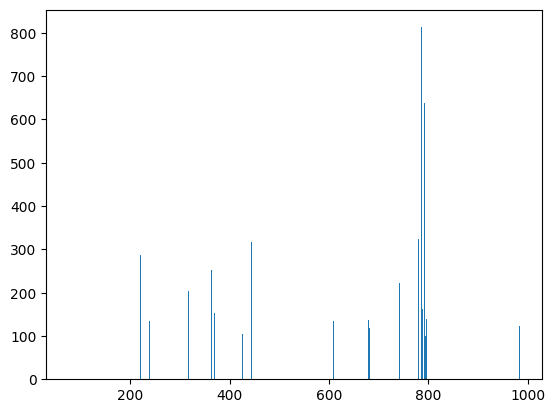

In [84]:
frecuencia = {}
for id in df['ID_GRD']:
    if id not in frecuencia:
        frecuencia[id] = 1
    else:
        frecuencia[id] += 1

moda = {}
for i in frecuencia:
    if frecuencia[i] >= 100:
        moda[i] = frecuencia[i]

ejex = list(moda.keys())
ejey = list(moda.values())    

nuevos_ids = {}
id = 1
for a in ejex:
    nuevos_ids[a] = id
    id += 1

print(len(moda))
plt.bar(ejex, ejey)
#sns.histplot(df['ID_GRD'], bins=40, kde=True)

In [81]:
nuevo_dataset = pd.DataFrame()

fila = 0 
for a in df['ID_GRD']:
    if a not in ejex:
        pass
    else:
        fila_copia = df.iloc[fila]
        nuevo_dataset = pd.concat([nuevo_dataset, pd.DataFrame([fila_copia])], ignore_index=True)
    fila += 1

nuevo_dataset['ID_GRD'] = nuevo_dataset['ID_GRD'].replace(nuevos_ids)
nuevo_dataset.head()

,ID_diagnostico 1,ID_diagnostico 2,ID_diagnostico 3,ID_diagnostico 4,ID_diagnostico 5,ID_diagnostico 6,ID_diagnostico 7,ID_diagnostico 8,ID_diagnostico 9,ID_diagnostico 10,...,ID_procedimiento 24,ID_procedimiento 25,ID_procedimiento 26,ID_procedimiento 27,ID_procedimiento 28,ID_procedimiento 29,ID_procedimiento 30,Edad en años,Sexo (Desc),ID_GRD
0,4872,4810,10630,1874,2373,2370,4381,10623,4321,12717,...,2334,11,15,4555,4570,4574,4576,61,1,1
1,14587,39106,13299,13385,23644,4425,4207,14749,14738,10712,...,4038,4108,4103,4277,4567,4441,1756,30,1,1
2,14738,4202,4380,39275,39329,39179,14591,39110,4913,4805,...,4555,4570,4571,4574,4579,4582,4196,37,0,1
3,14738,4202,4423,12771,12632,12603,8186,12615,70,39329,...,4579,4582,4196,4204,4206,4207,4208,59,1,1
4,10620,4881,14738,4425,3913,12785,227,895,39158,14749,...,3828,3865,3751,3859,3786,1756,1764,77,0,1


<BarContainer object of 33 artists>

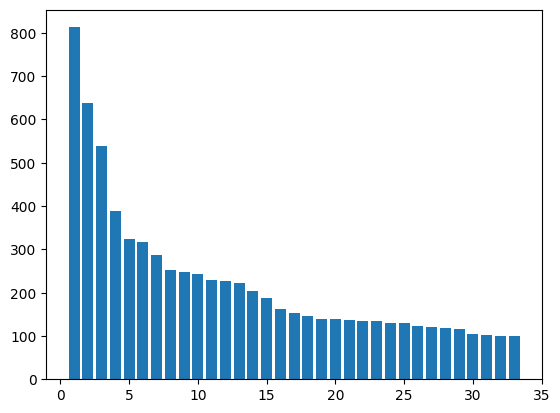

In [85]:
ejey = nuevo_dataset['ID_GRD'].value_counts()
ejex = list(nuevos_ids.values())

plt.bar(ejex, ejey)